# Standard vs Polynomial Electrostatic Lens

This notebook compares two lens section implementations under matched conditions:

- `ElectrostaticQuadrupoleLens` (standard ideal quadrupole field)
- `ElectrostaticLensPolynomial` (default polynomial field model)

Everything else is intentionally held fixed: geometry, voltage, Stark potential, particle species, and initial ensemble.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

from centrex_trajectories import (
    Force,
    PropagationOptions,
    propagate_trajectories,
    random_generation,
)
from centrex_trajectories.beamline_objects import (
    Bore,
    ElectrostaticLensPolynomial,
    ElectrostaticQuadrupoleLens,
    RectangularAperture,
    Section,
)
from centrex_trajectories.particles import TlF

plt.rcParams.update({"font.size": 12})

R = 1.75 * 25.4e-3 / 2  # [m]
V = 24_000.0  # [V]
LENS_START = 0.20  # [m]
LENS_STOP = 0.80  # [m]
LENS_MID = 0.5 * (LENS_START + LENS_STOP)
DETECTOR_Z = 1.15  # [m]
DETECTOR_WX = 6e-3  # [m]
DETECTOR_WY = 6e-3  # [m]

N_PARTICLES = 2000
N_TRAJ_LINES = 30
SEED = 20260320

particle = TlF()
force = Force(0.0, 0.0, 0.0)
options = PropagationOptions(verbose=False, n_cores=1)

print(f"Lens radius R = {R * 1e3:.3f} mm")
print(f"Lens voltage V = {V / 1e3:.1f} kV")
print(f"Lens region z = [{LENS_START:.2f}, {LENS_STOP:.2f}] m")
print(
    f"Detector aperture at z = {DETECTOR_Z:.2f} m with wx=wy={DETECTOR_WX * 1e3:.1f} mm"
)

Lens radius R = 22.225 mm
Lens voltage V = 24.0 kV
Lens region z = [0.20, 0.80] m
Detector aperture at z = 1.15 m with wx=wy=6.0 mm


In [2]:
lens_standard = ElectrostaticQuadrupoleLens(
    name="Lens Standard",
    objects=[
        Bore(
            x=0.0,
            y=0.0,
            z=LENS_START,
            length=LENS_STOP - LENS_START,
            radius=R,
        )
    ],
    start=LENS_START,
    stop=LENS_STOP,
    V=V,
    R=R,
    save_collisions=False,
)

lens_polynomial = ElectrostaticLensPolynomial(
    name="Lens Polynomial",
    objects=[
        Bore(
            x=0.0,
            y=0.0,
            z=LENS_START,
            length=LENS_STOP - LENS_START,
            radius=R,
        )
    ],
    start=LENS_START,
    stop=LENS_STOP,
    V=V,
    R=R,
    save_collisions=False,
)

# Inline sanity checks: both models instantiated with shared geometry and finite fields.
assert isinstance(lens_standard, ElectrostaticQuadrupoleLens)
assert isinstance(lens_polynomial, ElectrostaticLensPolynomial)

_probe_x = np.array([0.0, 0.25 * R, 0.5 * R])
_probe_y = np.array([0.0, 0.25 * R, 0.5 * R])
_probe_z = np.full_like(_probe_x, LENS_MID)
assert np.all(np.isfinite(lens_standard.electric_field(_probe_x, _probe_y, _probe_z)))
assert np.all(np.isfinite(lens_polynomial.electric_field(_probe_x, _probe_y, _probe_z)))

print("Lens construction checks passed.")

Lens construction checks passed.


## 1) Radial Field Profile at Lens Midpoint

Sample along `x=0`, `y=r`, `z=LENS_MID`.

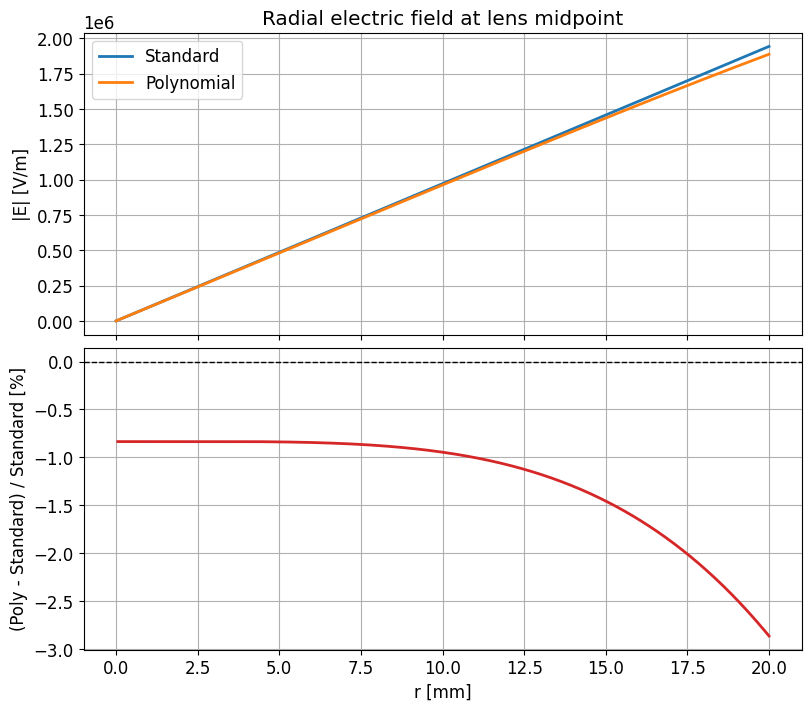

In [3]:
r = np.linspace(0.0, 0.9 * R, 400)
x_line = np.zeros_like(r)
y_line = r.copy()
z_line = np.full_like(r, LENS_MID)

E_standard = lens_standard.electric_field(x_line, y_line, z_line)
E_poly_vec = lens_polynomial.electric_field(x_line, y_line, z_line)
E_poly = np.linalg.norm(E_poly_vec, axis=0)

# Inline sanity checks: expected shapes and finite values.
assert E_standard.shape == r.shape
assert E_poly.shape == r.shape
assert np.all(np.isfinite(E_standard))
assert np.all(np.isfinite(E_poly))

E_rel = np.divide(
    E_poly - E_standard,
    E_standard,
    out=np.full_like(E_standard, np.nan),
    where=E_standard > 0.0,
)

fig, axes = plt.subplots(2, 1, figsize=(8, 7), sharex=True, constrained_layout=True)

axes[0].plot(r * 1e3, E_standard, lw=2, label="Standard")
axes[0].plot(r * 1e3, E_poly, lw=2, label="Polynomial")
axes[0].set_ylabel("|E| [V/m]")
axes[0].set_title("Radial electric field at lens midpoint")
axes[0].grid(True)
axes[0].legend()

axes[1].plot(r * 1e3, 100 * E_rel, color="tab:red", lw=2)
axes[1].axhline(0.0, color="k", ls="--", lw=1)
axes[1].set_xlabel("r [mm]")
axes[1].set_ylabel("(Poly - Standard) / Standard [%]")
axes[1].grid(True)

plt.show()

## 2) Radial Force Profile at Lens Midpoint

Compare `Fy` and transverse force magnitude along the same radial line.

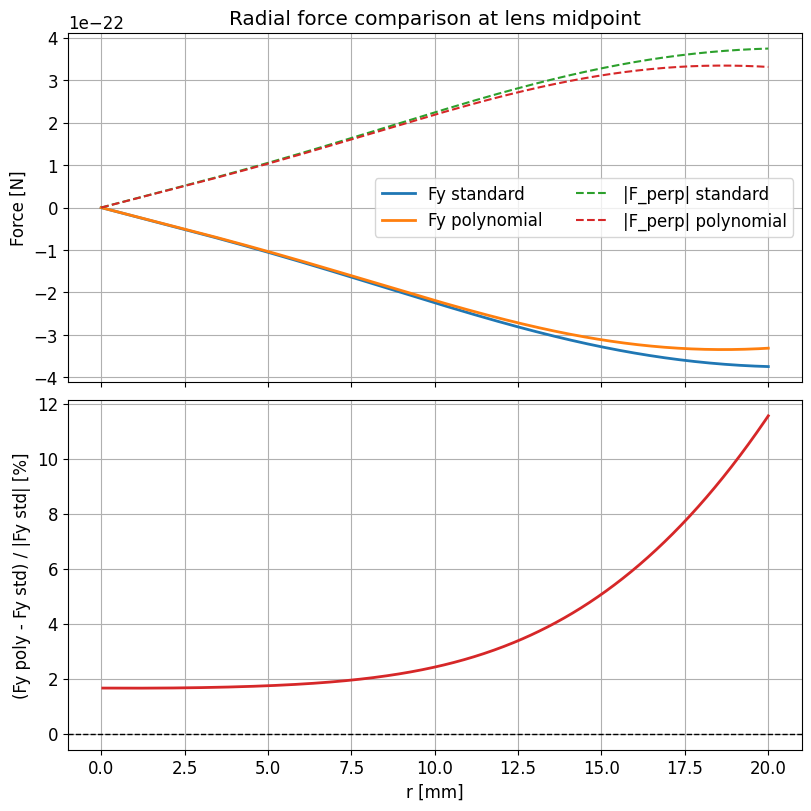

In [4]:
fx_s, fy_s, fz_s = lens_standard.force(0.0, x_line, y_line, z_line)
fx_p, fy_p, fz_p = lens_polynomial.force(0.0, x_line, y_line, z_line)

Fperp_s = np.sqrt(fx_s**2 + fy_s**2)
Fperp_p = np.sqrt(fx_p**2 + fy_p**2)

assert fy_s.shape == r.shape
assert fy_p.shape == r.shape
assert np.all(np.isfinite(Fperp_s))
assert np.all(np.isfinite(Fperp_p))

Fy_rel = np.divide(
    fy_p - fy_s,
    np.abs(fy_s),
    out=np.full_like(fy_s, np.nan),
    where=np.abs(fy_s) > 0.0,
)

fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharex=True, constrained_layout=True)

axes[0].plot(r * 1e3, fy_s, lw=2, label="Fy standard")
axes[0].plot(r * 1e3, fy_p, lw=2, label="Fy polynomial")
axes[0].plot(r * 1e3, Fperp_s, lw=1.5, ls="--", label="|F_perp| standard")
axes[0].plot(r * 1e3, Fperp_p, lw=1.5, ls="--", label="|F_perp| polynomial")
axes[0].set_ylabel("Force [N]")
axes[0].set_title("Radial force comparison at lens midpoint")
axes[0].grid(True)
axes[0].legend(ncol=2)

axes[1].plot(r * 1e3, 100 * Fy_rel, color="tab:red", lw=2)
axes[1].axhline(0.0, color="k", ls="--", lw=1)
axes[1].set_xlabel("r [mm]")
axes[1].set_ylabel("(Fy poly - Fy std) / |Fy std| [%]")
axes[1].grid(True)

plt.show()

## 3) 2D Transverse Map at Lens Midpoint

Compute `|E|` on an `x-y` grid and inspect map-level differences inside the bore.
This section shows both absolute difference (`poly - standard`) and percentage difference (`100*(poly-standard)/standard`).


Field difference inside bore: mean=-0.81% max_abs=3.95%


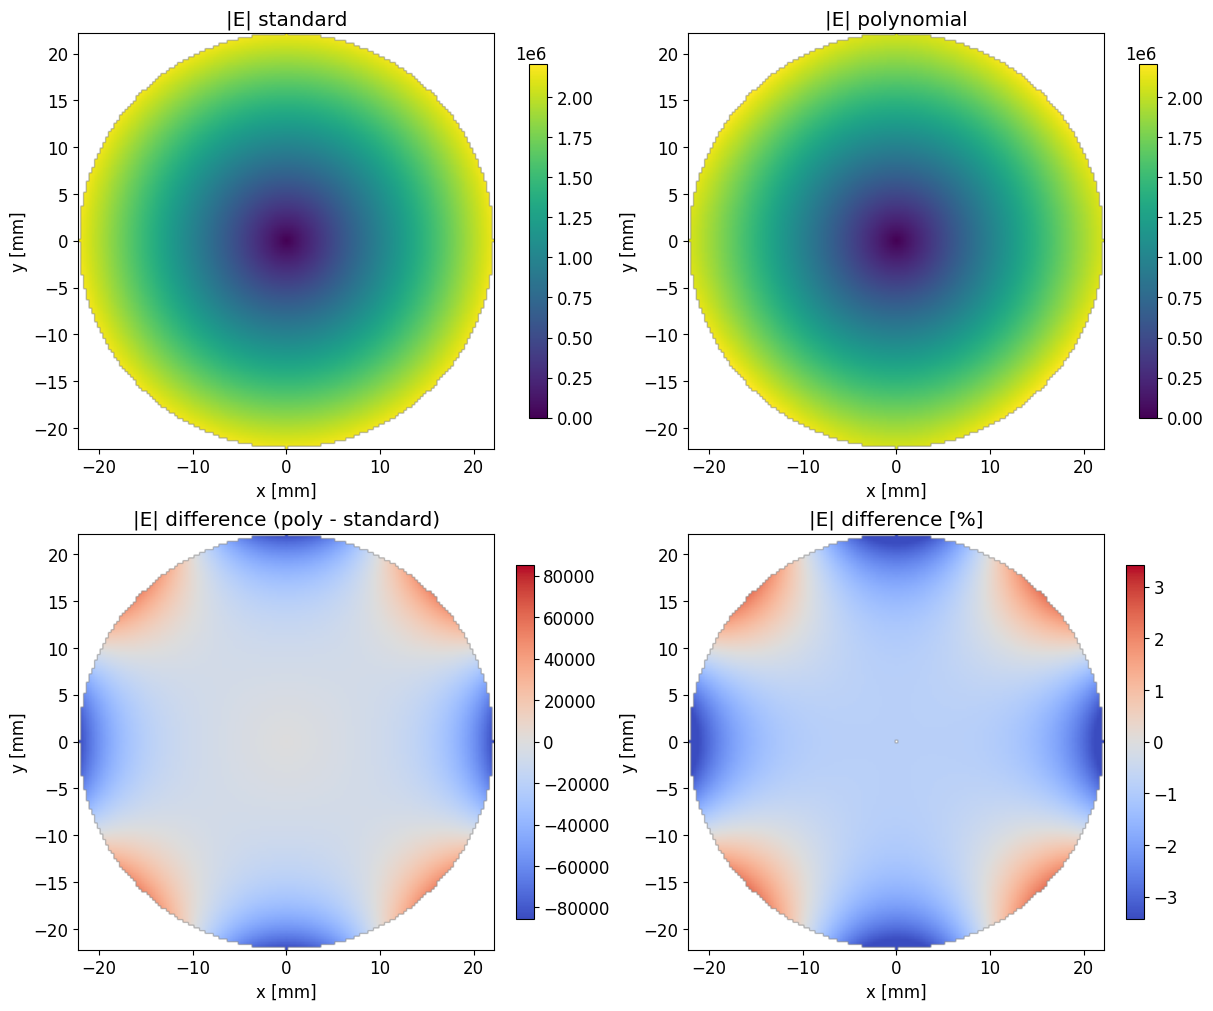

In [5]:
grid = np.linspace(-R, R, 151)
xx, yy = np.meshgrid(grid, grid, indexing="xy")

xf = xx.ravel()
yf = yy.ravel()
zf = np.full_like(xf, LENS_MID)

field_standard_map = lens_standard.electric_field(xf, yf, zf).reshape(xx.shape)
field_poly_map = np.linalg.norm(
    lens_polynomial.electric_field(xf, yf, zf), axis=0
).reshape(xx.shape)
field_delta_map = field_poly_map - field_standard_map
field_delta_pct_map = np.divide(
    100.0 * field_delta_map,
    field_standard_map,
    out=np.full_like(field_standard_map, np.nan),
    where=field_standard_map > 0.0,
)

mask_inside = (xx**2 + yy**2) <= R**2
field_standard_map = np.where(mask_inside, field_standard_map, np.nan)
field_poly_map = np.where(mask_inside, field_poly_map, np.nan)
field_delta_map = np.where(mask_inside, field_delta_map, np.nan)
field_delta_pct_map = np.where(mask_inside, field_delta_pct_map, np.nan)

assert np.all(np.isfinite(field_standard_map[mask_inside]))
assert np.all(np.isfinite(field_poly_map[mask_inside]))

extent_mm = [grid.min() * 1e3, grid.max() * 1e3, grid.min() * 1e3, grid.max() * 1e3]
vmax = np.nanmax([field_standard_map, field_poly_map])

fig, axes = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
ax = axes.ravel()

im0 = ax[0].imshow(
    field_standard_map, extent=extent_mm, origin="lower", vmin=0.0, vmax=vmax
)
ax[0].set_title("|E| standard")
ax[0].set_xlabel("x [mm]")
ax[0].set_ylabel("y [mm]")
fig.colorbar(im0, ax=ax[0], shrink=0.85)

im1 = ax[1].imshow(
    field_poly_map, extent=extent_mm, origin="lower", vmin=0.0, vmax=vmax
)
ax[1].set_title("|E| polynomial")
ax[1].set_xlabel("x [mm]")
ax[1].set_ylabel("y [mm]")
fig.colorbar(im1, ax=ax[1], shrink=0.85)

delta_lim = np.nanmax(np.abs(field_delta_map))
im2 = ax[2].imshow(
    field_delta_map,
    extent=extent_mm,
    origin="lower",
    cmap="coolwarm",
    vmin=-delta_lim,
    vmax=delta_lim,
)
ax[2].set_title("|E| difference (poly - standard)")
ax[2].set_xlabel("x [mm]")
ax[2].set_ylabel("y [mm]")
fig.colorbar(im2, ax=ax[2], shrink=0.85)

# Use a robust color limit so near-axis division by very small |E| doesn't dominate.
pct_lim = np.nanpercentile(np.abs(field_delta_pct_map), 99.0)
if not np.isfinite(pct_lim) or pct_lim == 0.0:
    pct_lim = np.nanmax(np.abs(field_delta_pct_map))
if not np.isfinite(pct_lim) or pct_lim == 0.0:
    pct_lim = 1.0

im3 = ax[3].imshow(
    field_delta_pct_map,
    extent=extent_mm,
    origin="lower",
    cmap="coolwarm",
    vmin=-pct_lim,
    vmax=pct_lim,
)
ax[3].set_title("|E| difference [%]")
ax[3].set_xlabel("x [mm]")
ax[3].set_ylabel("y [mm]")
fig.colorbar(im3, ax=ax[3], shrink=0.85)

valid_pct = np.isfinite(field_delta_pct_map)
if np.any(valid_pct):
    print(
        f"Field difference inside bore: mean={np.nanmean(field_delta_pct_map):.2f}% "
        f"max_abs={np.nanmax(np.abs(field_delta_pct_map)):.2f}%"
    )

plt.show()


## 4) Trajectory Comparison Through Matched Beamlines

Use one shared initial ensemble and identical propagation options. The only difference is the lens model.

In [6]:
rng = np.random.default_rng(SEED)
coordinates_init = random_generation.generate_random_coordinates_normal_circle(
    sigma=0.6e-3,
    number=N_PARTICLES,
    z=0.0,
    rng=rng,
)
velocities_init = random_generation.generate_random_velocities_normal(
    vx=0.0,
    vy=0.0,
    vz=184.0,
    sigma_vx=0.8,
    sigma_vy=0.8,
    sigma_vz=8.0,
    number=N_PARTICLES,
    rng=rng,
)


def build_sections(lens):
    pre_drift = Section(
        name="Pre Drift",
        objects=[],
        start=0.0,
        stop=lens.start,
        save_collisions=False,
    )
    detector = Section(
        name="Detector",
        objects=[
            RectangularAperture(
                x=0.0,
                y=0.0,
                z=DETECTOR_Z,
                wx=DETECTOR_WX,
                wy=DETECTOR_WY,
            )
        ],
        start=lens.stop,
        stop=DETECTOR_Z + 0.010,
        save_collisions=False,
    )
    return [pre_drift, lens, detector]


def run_model(lens):
    sections = build_sections(lens)
    section_data, trajectories = propagate_trajectories(
        sections,
        coordinates_init,
        velocities_init,
        particle,
        force=force,
        options=options,
    )
    return sections, section_data, trajectories


sections_std, section_data_std, trajectories_std = run_model(lens_standard)
sections_poly, section_data_poly, trajectories_poly = run_model(lens_polynomial)


def final_xy(trajectories):
    if len(trajectories) == 0:
        return np.array([], dtype=float), np.array([], dtype=float)
    x_final = np.array([traj.x[-1] for traj in trajectories.values()], dtype=float)
    y_final = np.array([traj.y[-1] for traj in trajectories.values()], dtype=float)
    return x_final, y_final


x_std_final, y_std_final = final_xy(trajectories_std)
x_poly_final, y_poly_final = final_xy(trajectories_poly)

n_surv_std = len(trajectories_std)
n_surv_poly = len(trajectories_poly)

transmission_std = n_surv_std / N_PARTICLES
transmission_poly = n_surv_poly / N_PARTICLES

rms_x_std = np.sqrt(np.mean(x_std_final**2)) if n_surv_std > 0 else np.nan
rms_y_std = np.sqrt(np.mean(y_std_final**2)) if n_surv_std > 0 else np.nan
rms_x_poly = np.sqrt(np.mean(x_poly_final**2)) if n_surv_poly > 0 else np.nan
rms_y_poly = np.sqrt(np.mean(y_poly_final**2)) if n_surv_poly > 0 else np.nan

# Inline sanity checks for trajectory metrics.
assert np.isfinite(transmission_std)
assert np.isfinite(transmission_poly)
if n_surv_std > 0:
    assert np.isfinite(np.array([rms_x_std, rms_y_std])).all()
if n_surv_poly > 0:
    assert np.isfinite(np.array([rms_x_poly, rms_y_poly])).all()

print(f"Initial trajectories: {N_PARTICLES}")
print(f"Survivors (standard):   {n_surv_std} ({100 * transmission_std:.2f}%)")
print(f"Survivors (polynomial): {n_surv_poly} ({100 * transmission_poly:.2f}%)")
if n_surv_std == 0 or n_surv_poly == 0:
    print(
        "Warning: one model has zero survivors. Increase detector aperture or relax initial spread."
    )
else:
    print("Both models have non-empty survivor sets.")

Initial trajectories: 2000
Survivors (standard):   646 (32.30%)
Survivors (polynomial): 643 (32.15%)
Both models have non-empty survivor sets.


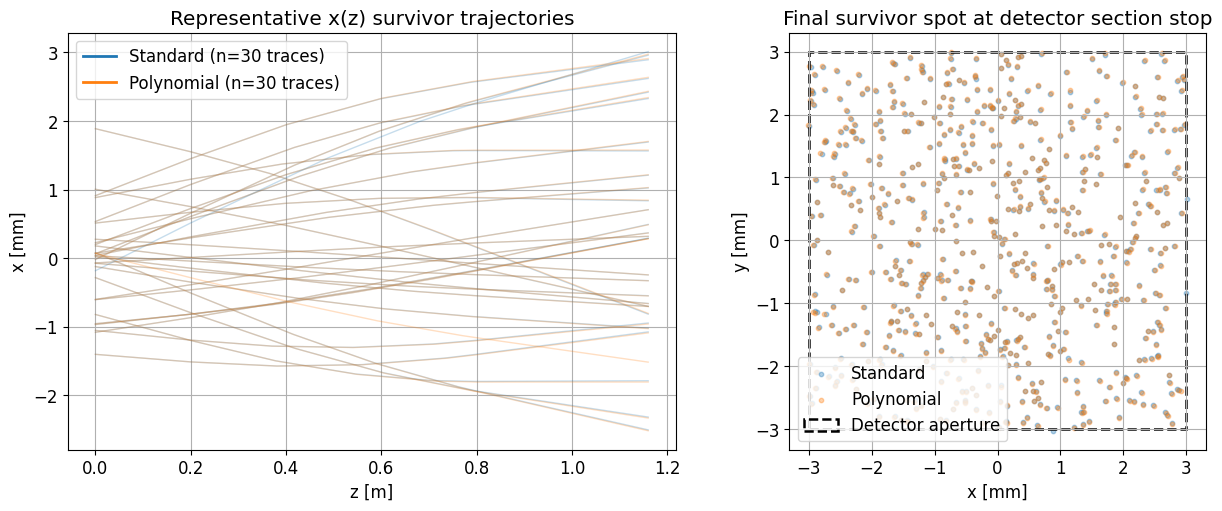

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)


def add_xz_bundle(ax, trajectories, color, label):
    keys = sorted(trajectories.keys())[:N_TRAJ_LINES]
    for key in keys:
        tr = trajectories[key]
        ax.plot(tr.z, tr.x * 1e3, color=color, alpha=0.25, lw=1.0)
    ax.plot([], [], color=color, lw=2, label=f"{label} (n={len(keys)} traces)")


add_xz_bundle(axes[0], trajectories_std, "tab:blue", "Standard")
add_xz_bundle(axes[0], trajectories_poly, "tab:orange", "Polynomial")
axes[0].set_xlabel("z [m]")
axes[0].set_ylabel("x [mm]")
axes[0].set_title("Representative x(z) survivor trajectories")
axes[0].grid(True)
axes[0].legend()

if n_surv_std > 0:
    axes[1].scatter(
        x_std_final * 1e3, y_std_final * 1e3, s=10, alpha=0.35, label="Standard"
    )
if n_surv_poly > 0:
    axes[1].scatter(
        x_poly_final * 1e3, y_poly_final * 1e3, s=10, alpha=0.35, label="Polynomial"
    )

half_wx_mm = 0.5 * DETECTOR_WX * 1e3
half_wy_mm = 0.5 * DETECTOR_WY * 1e3
axes[1].add_patch(
    Rectangle(
        (-half_wx_mm, -half_wy_mm),
        2 * half_wx_mm,
        2 * half_wy_mm,
        fill=False,
        color="k",
        lw=1.8,
        ls="--",
        label="Detector aperture",
    )
)
axes[1].set_aspect("equal")
axes[1].set_xlabel("x [mm]")
axes[1].set_ylabel("y [mm]")
axes[1].set_title("Final survivor spot at detector section stop")
axes[1].grid(True)
axes[1].legend(loc="best")

plt.show()

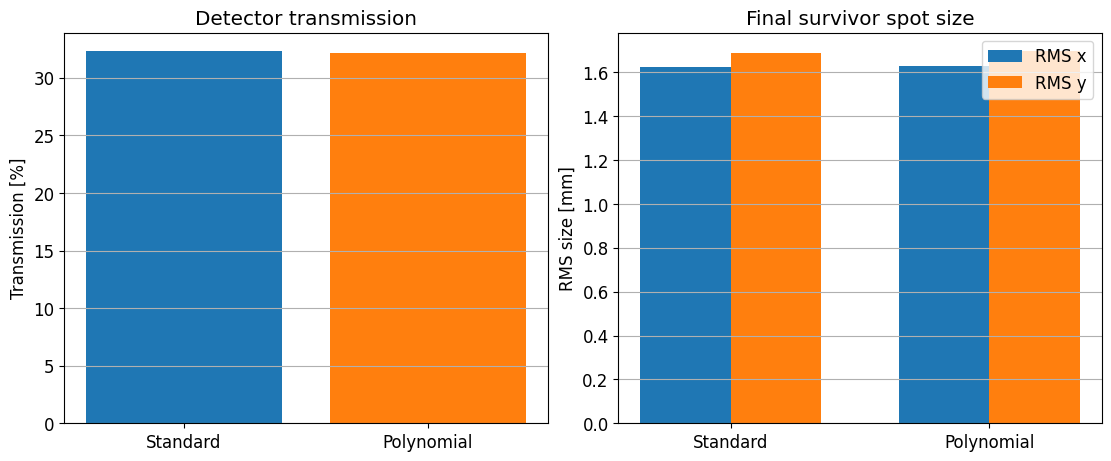

In [8]:
labels = ["Standard", "Polynomial"]
transmissions = np.array([transmission_std, transmission_poly])
rms_x_vals = np.array([rms_x_std, rms_x_poly])
rms_y_vals = np.array([rms_y_std, rms_y_poly])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)

axes[0].bar(labels, 100 * transmissions, color=["tab:blue", "tab:orange"])
axes[0].set_ylabel("Transmission [%]")
axes[0].set_title("Detector transmission")
axes[0].grid(axis="y")

if np.all(np.isfinite(rms_x_vals)) and np.all(np.isfinite(rms_y_vals)):
    xloc = np.arange(len(labels))
    width = 0.35
    axes[1].bar(xloc - width / 2, 1e3 * rms_x_vals, width=width, label="RMS x")
    axes[1].bar(xloc + width / 2, 1e3 * rms_y_vals, width=width, label="RMS y")
    axes[1].set_xticks(xloc)
    axes[1].set_xticklabels(labels)
    axes[1].set_ylabel("RMS size [mm]")
    axes[1].set_title("Final survivor spot size")
    axes[1].grid(axis="y")
    axes[1].legend()
else:
    axes[1].text(0.5, 0.5, "RMS undefined (no survivors)", ha="center", va="center")
    axes[1].set_axis_off()

plt.show()

## 5) Interpretation

- The standard lens gives an idealized radial quadrupole field (`|E| ~ r`), while the polynomial lens captures departures from that ideal.
- Differences in field/force profiles propagate into downstream observables (transmission and spot size).
- Prefer the standard model for quick scans and conceptual studies; prefer the polynomial model when realistic field structure is important for quantitative predictions.